In [4]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from scipy.interpolate import interp1d

# --- パスの設定 ---
cocoa_root = "/home/tanida/cocoa_v41/cocoa/Cocoa"
mgcamb_path = os.path.join(cocoa_root, "external_modules/code/MGCAMB")
velocileptors_path = os.path.join(cocoa_root, "external_modules/code/velocileptors")

sys.path.insert(0, mgcamb_path)
sys.path.append(velocileptors_path)

import camb
from camb import model
from velocileptors.LPT.moment_expansion_fftw import MomentExpansion

In [9]:
def get_mgcamb_data(mu0_val, target_sigma8=0.8120, z_eff=0.6264):
    """
    MGCAMBを使用して、z_effでの線形パワースペクトル P(k) と成長率 f を取得する
    (z=0でのsigma8をtarget_sigma8に規格化)
    """
    # 以前の検証で特定した Planck パラメータ
    h = 0.6732
    ob = 0.049389
    oc = 0.26503
    ns = 0.96605
    
    params = camb.CAMBparams()
    params.set_cosmology(H0=h*100, ombh2=ob*h**2, omch2=oc*h**2, mnu=0.0, omk=0, tau=0.0697186, nnu=3.046)
    
    # MGCAMB設定 (mu-Sigmaモデル)
    params.MG_wrapped = True
    params.MG_flag = 1
    params.pure_MG_flag = 2
    # params.GRtrans = 0.2
    params.muSigma_par = 1
    params.mu0 = mu0_val
    params.sigma0 = 0.0
    params.InitPower.set_params(As=2.1e-09, ns=ns)

    # 1. z=0.0でのsigma8を確認してAsをスケール
    params.set_matter_power(redshifts=[0.0, z_eff], kmax=20.0, nonlinear=False)
    results = camb.get_results(params)
    s8_z0 = results.get_sigma8_0()
    print("s8_z0: ", s8_z0)
    
    new_As = 2.1e-09 * (target_sigma8 / s8_z0)**2
    params.InitPower.set_params(As=new_As, ns=ns)
    
    # 2. 本計算
    results = camb.get_results(params)
    kh, z_out, pk = results.get_matter_power_spectrum(minkh=1e-4, maxkh=20.0, npoints=2000)
    
    idx_zeff = np.argmin(np.abs(np.array(z_out) - z_eff))
    pk_zeff = pk[idx_zeff, :]
    
    # f = dlnD/dlna の取得
    fsigma8 = results.get_fsigma8()
    f_zeff = fsigma8[idx_zeff] / results.get_sigma8()[idx_zeff]

    print("new_s8_z0: ", results.get_sigma8_0())
    
    return kh, pk_zeff, f_zeff, results.get_sigma8()[idx_zeff]

def compute_pt_multipoles(k_lin, p_lin, f_z, sigma8_z):
    """
    velocileptors (LPT Moment Expansion) を使用して多重極を計算
    """
    mome = MomentExpansion(k_lin, p_lin)
    
    # バイアスパラメータの設定 (Velo's Velo vs Kaiser.ipynb の例に倣う)
    # (1 + b1) * sigma8(z) = 1.34 と仮定
    b1 = (1.34 / sigma8_z) - 1.0
    
    # その他の高次パラメータは0（線形比較のため）
    pars = [b1, 0, 0, 0, 0, 0, 0, 0, 0] # [b1, b2, bs, b3, alpha0, alpha2, alpha4, SN0, SN2]
    
    k_vec, p0, p2, p4 = mome.compute_redshift_space_power_multipoles(pars, f_z, reduced=True)
    return k_vec, p0, p2, p4

Note: redshifts have been re-sorted (earliest first)
z_out_pk:  [0.0, 0.6264]
idx_pk:  1
z_out_trans:  [0.6264 0.    ]
idx_trans:  0

--- MGCAMB Debug (mu0=0.0) ---
  Target s8(z=0)   : 0.812000
  Result s8(z=0)   : 0.812000
  Result s8(z_eff) : 0.586333 (z=0.6264)
  Growth rate f    : 0.7985
Note: redshifts have been re-sorted (earliest first)
z_out_pk:  [0.0, 0.6264]
idx_pk:  1
z_out_trans:  [0.6264 0.    ]
idx_trans:  0

--- MGCAMB Debug (mu0=1.0) ---
  Target s8(z=0)   : 0.812000
  Result s8(z=0)   : 0.812000
  Result s8(z_eff) : 0.545444 (z=0.6264)
  Growth rate f    : 0.9121


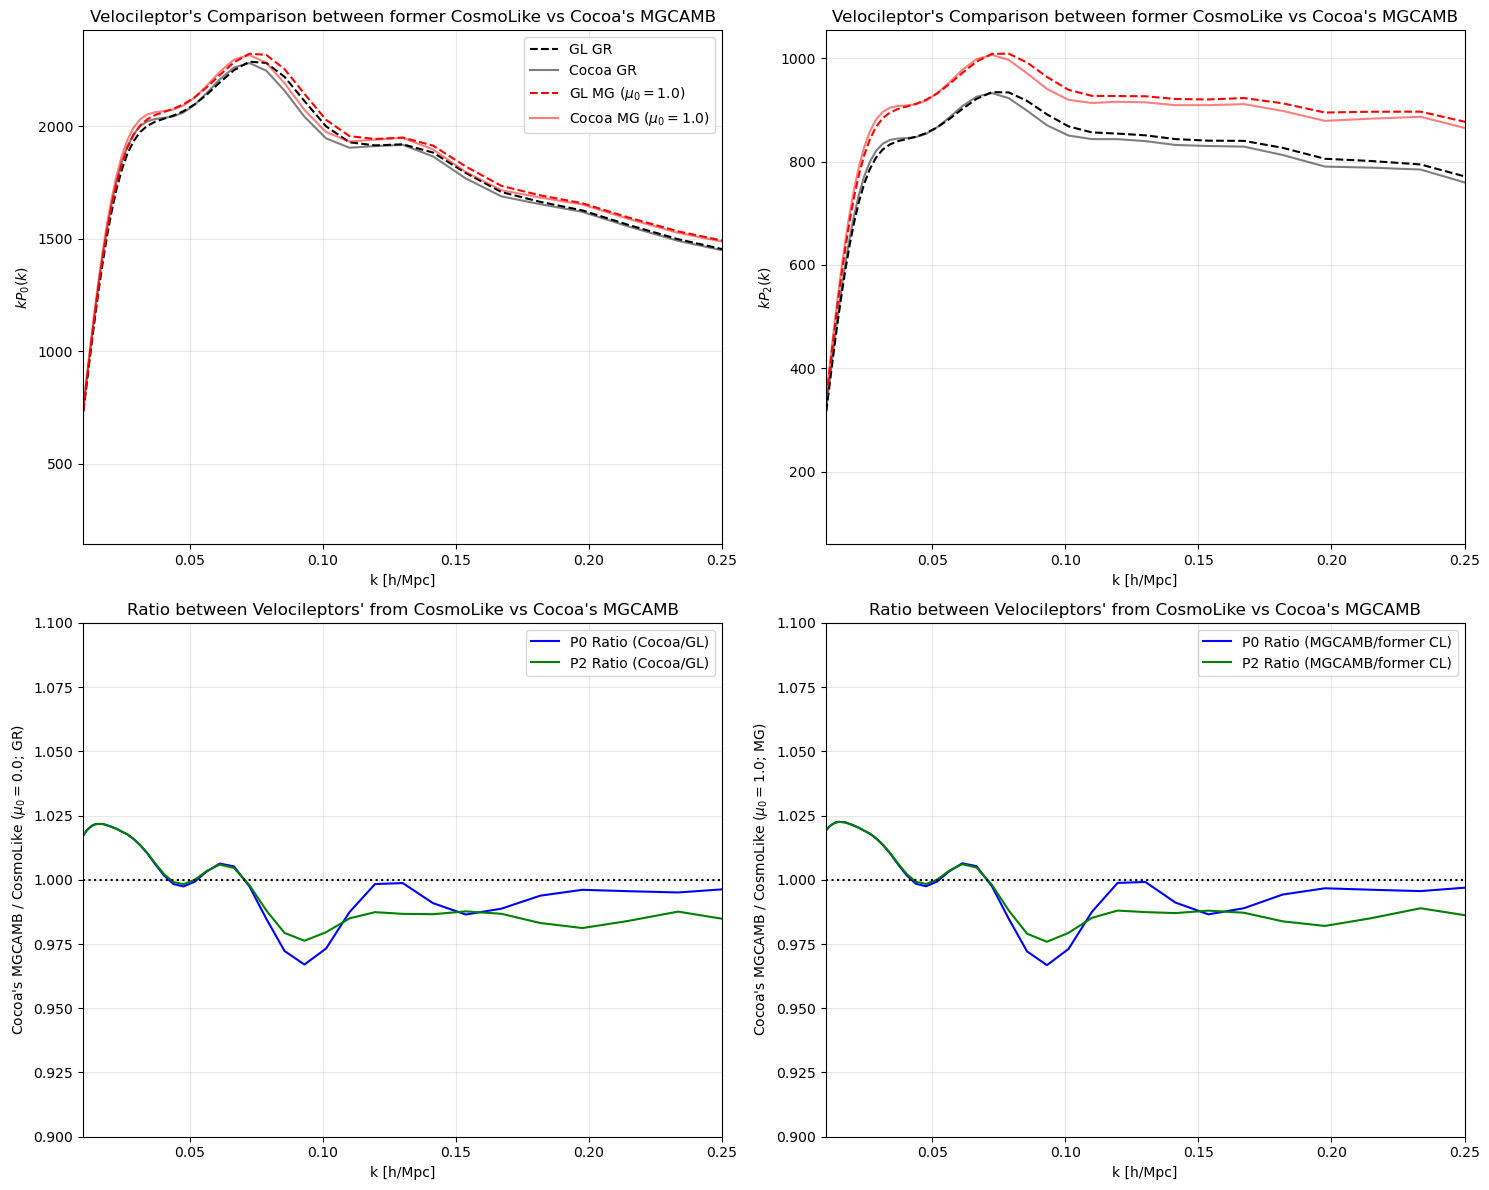

In [55]:
# --- メイン処理 ---
z_eff = 0.6264
target_sigma8 = 0.8120
gl_path = "/home/tanida/GL/valid_test/power/"

# 1. GLデータの読み込み
k_gl_gr, p_gl_gr = np.loadtxt(os.path.join(gl_path, "CMASS2_0000.dat"), unpack=True)
k_gl_mg, p_gl_mg = np.loadtxt(os.path.join(gl_path, "CMASS2_1000.dat"), unpack=True)

# 2. Cocoa (MGCAMB) データの生成
kh_cc_gr, p_cc_gr, f_gr, s8_gr = get_mgcamb_data(0.0, target_sigma8, z_eff)
kh_cc_mg, p_cc_mg, f_mg, s8_mg = get_mgcamb_data(1.0, target_sigma8, z_eff)

# 3. Velocileptors による PT 多重極の計算
# GLベース
kv_gl_gr, p0_gl_gr, p2_gl_gr, _ = compute_pt_multipoles(k_gl_gr, p_gl_gr, f_gr, s8_gr)
kv_gl_mg, p0_gl_mg, p2_gl_mg, _ = compute_pt_multipoles(k_gl_mg, p_gl_mg, f_mg, s8_mg)

# Cocoaベース
kv_cc_gr, p0_cc_gr, p2_cc_gr, _ = compute_pt_multipoles(kh_cc_gr, p_cc_gr, f_gr, s8_gr)
kv_cc_mg, p0_cc_mg, p2_cc_mg, _ = compute_pt_multipoles(kh_cc_mg, p_cc_mg, f_mg, s8_mg)

# --- プロット ---
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Monopole (GR & MG)
ax = axes[0, 0]
ax.plot(kv_gl_gr, kv_gl_gr * p0_gl_gr, 'k--', label='GL GR')
ax.plot(kv_cc_gr, kv_cc_gr * p0_cc_gr, 'k-', alpha=0.5, label='Cocoa GR')
ax.plot(kv_gl_mg, kv_gl_mg * p0_gl_mg, 'r--', label='GL MG ($\mu_0=1.0$)')
ax.plot(kv_cc_mg, kv_cc_mg * p0_cc_mg, 'r-', alpha=0.5, label='Cocoa MG ($\mu_0=1.0$)')
ax.set_title("Velocileptor's Comparison between former CosmoLike vs Cocoa's MGCAMB")
ax.set_ylabel('$k P_0(k)$')
ax.legend()

# Quadrupole (GR & MG)
ax = axes[0, 1]
ax.plot(kv_gl_gr, kv_gl_gr * p2_gl_gr, 'k--', label='GL GR')
ax.plot(kv_cc_gr, kv_cc_gr * p2_cc_gr, 'k-', alpha=0.5, label='Cocoa GR')
ax.plot(kv_gl_mg, kv_gl_mg * p2_gl_mg, 'r--', label='GL MG')
ax.plot(kv_cc_mg, kv_cc_mg * p2_cc_mg, 'r-', alpha=0.5, label='Cocoa MG')
ax.set_title("Velocileptor's Comparison between former CosmoLike vs Cocoa's MGCAMB")
ax.set_ylabel('$k P_2(k)$')

# Ratio Cocoa/GL (GR)
ax = axes[1, 0]
p0_ratio_gr = p0_cc_gr / interp1d(kv_gl_gr, p0_gl_gr, bounds_error=False)(kv_cc_gr)
p2_ratio_gr = p2_cc_gr / interp1d(kv_gl_gr, p2_gl_gr, bounds_error=False)(kv_cc_gr)
ax.plot(kv_cc_gr, p0_ratio_gr, 'b-', label='P0 Ratio (Cocoa/GL)')
ax.plot(kv_cc_gr, p2_ratio_gr, 'g-', label='P2 Ratio (Cocoa/GL)')
ax.axhline(1.0, color='k', linestyle=':')
ax.set_title("Ratio between Velocileptors' from CosmoLike vs Cocoa's MGCAMB")
ax.set_ylabel("Cocoa's MGCAMB / CosmoLike ($\mu_0=0.0$; GR)")
ax.set_ylim(0.90, 1.1)
ax.legend()

# Ratio Cocoa/GL (MG)
ax = axes[1, 1]
p0_ratio_mg = p0_cc_mg / interp1d(kv_gl_mg, p0_gl_mg, bounds_error=False)(kv_cc_mg)
p2_ratio_mg = p2_cc_mg / interp1d(kv_gl_mg, p2_gl_mg, bounds_error=False)(kv_cc_mg)
ax.plot(kv_cc_mg, p0_ratio_mg, 'b-', label='P0 Ratio (MGCAMB/former CL)')
ax.plot(kv_cc_mg, p2_ratio_mg, 'g-', label='P2 Ratio (MGCAMB/former CL)')
ax.axhline(1.0, color='k', linestyle=':')
ax.set_title("Ratio between Velocileptors' from CosmoLike vs Cocoa's MGCAMB")
ax.set_ylabel("Cocoa's MGCAMB / CosmoLike ($\mu_0=1.0$; MG)")
ax.set_ylim(0.90, 1.10)
ax.legend()

for ax in axes.flatten():
    ax.set_xlabel('k [h/Mpc]')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0.01, 0.25)

plt.tight_layout()
plt.show()

## 260111 \sigma_8を固定する場合

Note: redshifts have been re-sorted (earliest first)
z_out_pk:  [0.0, 0.6264]
idx_pk:  1
z_out_trans:  [0.6264 0.    ]
idx_trans:  0

--- MGCAMB Debug (mu0=0.0) ---
  Target s8(z=0)   : 0.812000
  Result s8(z=0)   : 0.812000
  Result s8(z_eff) : 0.586333 (z=0.6264)
  Growth rate f    : 0.7985
Note: redshifts have been re-sorted (earliest first)
z_out_pk:  [0.0, 0.6264]
idx_pk:  1
z_out_trans:  [0.6264 0.    ]
idx_trans:  0

--- MGCAMB Debug (mu0=1.0) ---
  Target s8(z=0)   : 0.812000
  Result s8(z=0)   : 0.812000
  Result s8(z_eff) : 0.545444 (z=0.6264)
  Growth rate f    : 0.9121


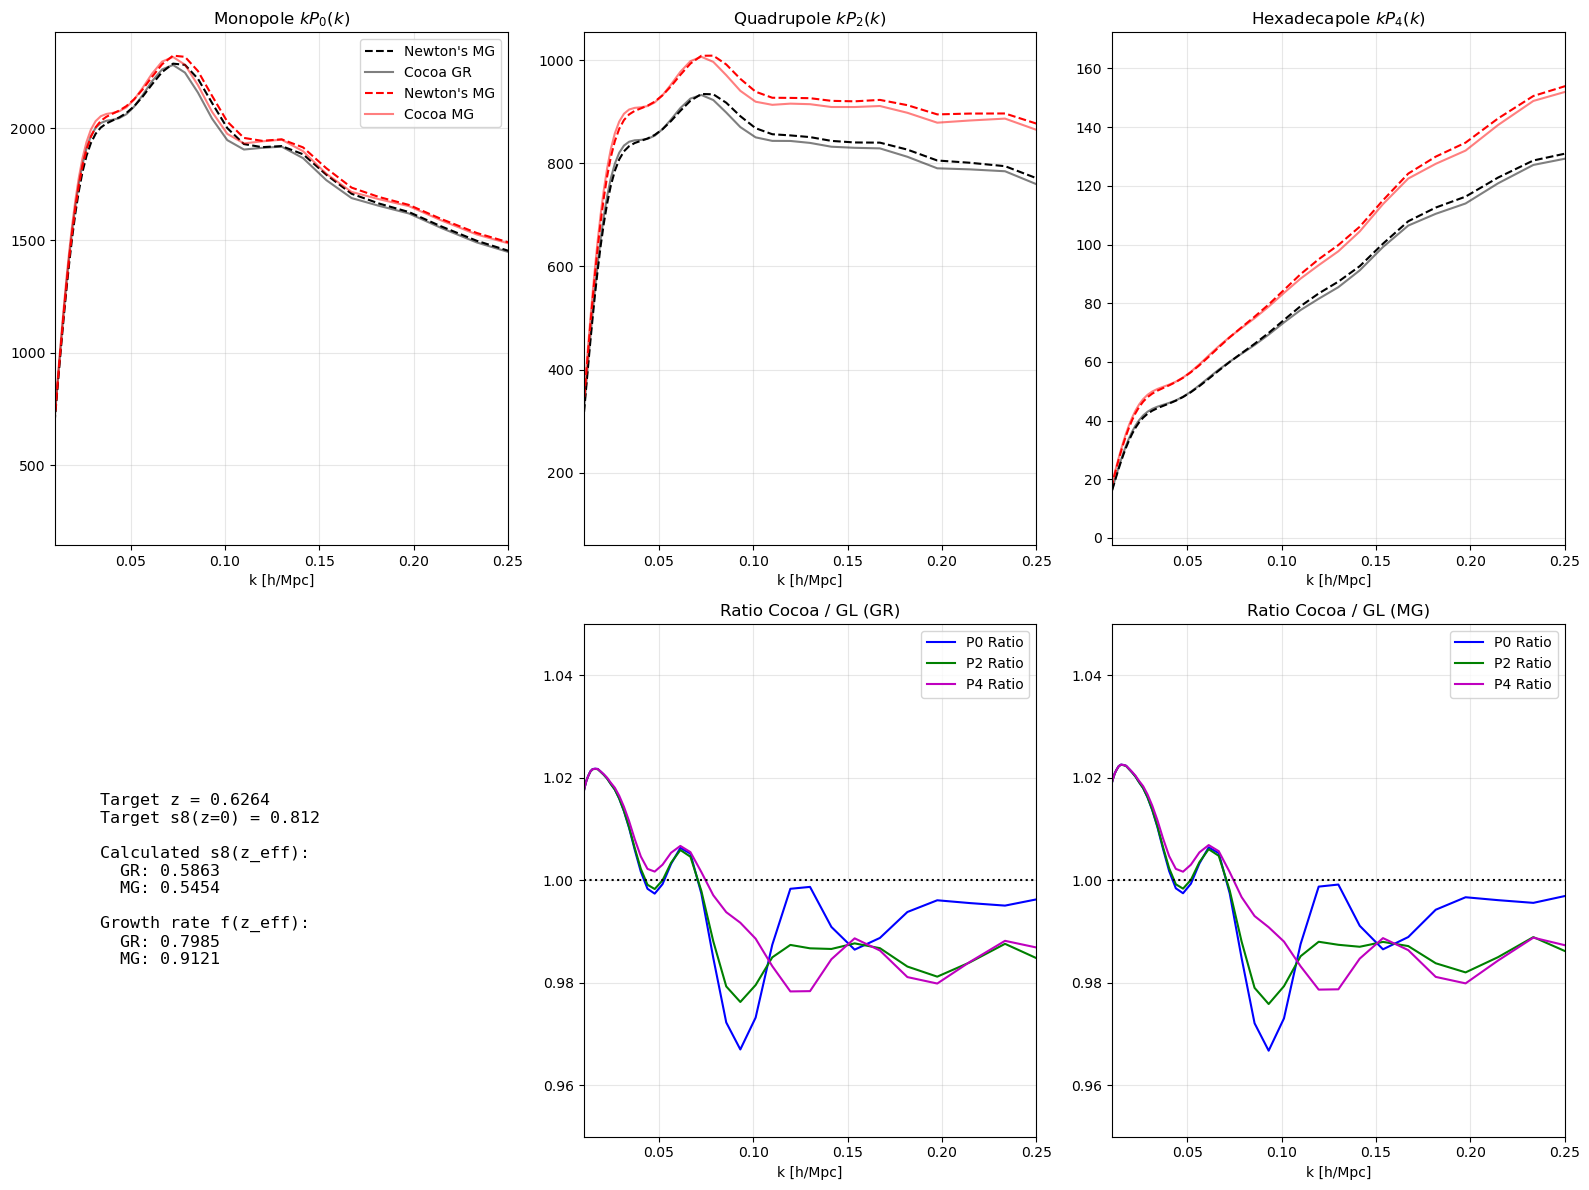

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from scipy.interpolate import interp1d

# --- パスの設定 ---
cocoa_root = "/home/tanida/cocoa_v41/cocoa/Cocoa"
mgcamb_path = os.path.join(cocoa_root, "external_modules/code/MGCAMB")
velocileptors_path = os.path.join(cocoa_root, "external_modules/code/velocileptors")

sys.path.insert(0, mgcamb_path)
sys.path.append(velocileptors_path)

import camb
from camb import model
from velocileptors.LPT.moment_expansion_fftw import MomentExpansion

def get_mgcamb_data(mu0_val, target_sigma8=0.8120, z_eff=0.6264):
    """
    MGCAMBを使用して、z_effでの線形パワースペクトル P(k) と成長率 f を取得する
    """
    h = 0.6732
    ob = 0.049389
    oc = 0.26503
    ns = 0.96605
    
    params = camb.CAMBparams()
    params.set_cosmology(H0=h*100, ombh2=ob*h**2, omch2=oc*h**2, mnu=0.0, omk=0, tau=0.0697186, nnu=3.046)
    
    params.MG_wrapped = True
    params.MG_flag = 1
    params.pure_MG_flag = 2
    params.muSigma_par = 1
    params.mu0 = mu0_val
    params.sigma0 = 0.0
    params.InitPower.set_params(As=2.1e-09, ns=ns)

    # 1. Asの規格化 (z=0でのsigma8をtarget_sigma8に)
    params.set_matter_power(redshifts=[0.0, z_eff], kmax=20.0, nonlinear=False)
    results = camb.get_results(params)
    s8_z0_initial = results.get_sigma8_0()
    
    new_As = 2.1e-09 * (target_sigma8 / s8_z0_initial)**2
    params.InitPower.set_params(As=new_As, ns=ns)
    
    # 2. 本計算
    results = camb.get_results(params)
    
    # --- 重要: インデックスの整合性を取るための処理 ---
    # get_matter_power_spectrum が返す z 順序を取得
    kh, z_out_pk, pk = results.get_matter_power_spectrum(minkh=1e-4, maxkh=20.0, npoints=2000)
    print("z_out_pk: ", z_out_pk)
    idx_pk = np.argmin(np.abs(np.array(z_out_pk) - z_eff))
    print("idx_pk: ", idx_pk)
    
    # sigma8 と fsigma8 が対応している z 順序を取得 (results.transfer_redshifts)
    z_out_trans = results.transfer_redshifts
    print("z_out_trans: ", np.array(z_out_trans))
    idx_trans = np.argmin(np.abs(np.array(z_out_trans) - z_eff))
    print("idx_trans: ", idx_trans)
    
    # 値の抽出
    pk_zeff = pk[idx_pk, :]
    s8_list = results.get_sigma8()
    fsigma8_list = results.get_fsigma8()
    
    s8_zeff = s8_list[idx_trans]
    f_zeff = fsigma8_list[idx_trans] / s8_zeff
    
    # z=0の確認
    idx_z0_trans = np.argmin(np.abs(np.array(z_out_trans) - 0.0))
    s8_z0_final = s8_list[idx_z0_trans]

    # デバッグ出力
    print(f"\n--- MGCAMB Debug (mu0={mu0_val}) ---")
    print(f"  Target s8(z=0)   : {target_sigma8:.6f}")
    print(f"  Result s8(z=0)   : {s8_z0_final:.6f}")
    print(f"  Result s8(z_eff) : {s8_zeff:.6f} (z={z_out_trans[idx_trans]:.4f})")
    print(f"  Growth rate f    : {f_zeff:.4f}")
    
    return kh, pk_zeff, f_zeff, s8_zeff

def compute_pt_multipoles(k_lin, p_lin, f_z, sigma8_z):
    mome = MomentExpansion(k_lin, p_lin)
    b1 = (1.34 / sigma8_z) - 1.0
    pars = [b1, 0, 0, 0, 0, 0, 0, 0, 0]
    k_vec, p0, p2, p4 = mome.compute_redshift_space_power_multipoles(pars, f_z, reduced=True)
    return k_vec, p0, p2, p4

# --- メイン処理 ---
z_eff = 0.6264
target_sigma8 = 0.8120
gl_path = "/home/tanida/GL/valid_test/power/"

k_gl_gr, p_gl_gr = np.loadtxt(os.path.join(gl_path, "CMASS2_0000.dat"), unpack=True)
k_gl_mg, p_gl_mg = np.loadtxt(os.path.join(gl_path, "CMASS2_1000.dat"), unpack=True)

kh_cc_gr, p_cc_gr, f_gr, s8_gr = get_mgcamb_data(0.0, target_sigma8, z_eff)
kh_cc_mg, p_cc_mg, f_mg, s8_mg = get_mgcamb_data(1.0, target_sigma8, z_eff)

kv_gl_gr, p0_gl_gr, p2_gl_gr, p4_gl_gr = compute_pt_multipoles(k_gl_gr, p_gl_gr, f_gr, s8_gr)
kv_gl_mg, p0_gl_mg, p2_gl_mg, p4_gl_mg = compute_pt_multipoles(k_gl_mg, p_gl_mg, f_mg, s8_mg)

kv_cc_gr, p0_cc_gr, p2_cc_gr, p4_cc_gr = compute_pt_multipoles(kh_cc_gr, p_cc_gr, f_gr, s8_gr)
kv_cc_mg, p0_cc_mg, p2_cc_mg, p4_cc_mg = compute_pt_multipoles(kh_cc_mg, p_cc_mg, f_mg, s8_mg)

# プロット部分は前回と同じ（比率の計算に lambda を使うなど）
fig, axes = plt.subplots(2, 3, figsize=(16, 12))

# P0
ax = axes[0, 0]
ax.plot(kv_gl_gr, kv_gl_gr * p0_gl_gr, 'k--', label="Newton's MG")
ax.plot(kv_cc_gr, kv_cc_gr * p0_cc_gr, 'k-', alpha=0.5, label='Cocoa GR')
ax.plot(kv_gl_mg, kv_gl_mg * p0_gl_mg, 'r--', label="Newton's MG")
ax.plot(kv_cc_mg, kv_cc_mg * p0_cc_mg, 'r-', alpha=0.5, label='Cocoa MG')
ax.set_title("Monopole $k P_0(k)$")
ax.legend()

# P2
ax = axes[0, 1]
ax.plot(kv_gl_gr, kv_gl_gr * p2_gl_gr, 'k--', label="Newton's MG")
ax.plot(kv_cc_gr, kv_cc_gr * p2_cc_gr, 'k-', alpha=0.5, label='Cocoa GR')
ax.plot(kv_gl_mg, kv_gl_mg * p2_gl_mg, 'r--', label="Newton's MG")
ax.plot(kv_cc_mg, kv_cc_mg * p2_cc_mg, 'r-', alpha=0.5, label='Cocoa MG')
ax.set_title("Quadrupole $k P_2(k)$")

# P4
ax = axes[0, 2]
ax.plot(kv_gl_gr, kv_gl_gr * p4_gl_gr, 'k--', label="Newton's MG")
ax.plot(kv_cc_gr, kv_cc_gr * p4_cc_gr, 'k-', alpha=0.5, label='Cocoa GR')
ax.plot(kv_gl_mg, kv_gl_mg * p4_gl_mg, 'r--', label='Newton's MG')
ax.plot(kv_cc_mg, kv_cc_mg * p4_cc_mg, 'r-', alpha=0.5, label='Cocoa MG')
ax.set_title("Hexadecapole $k P_4(k)$")

# Info
ax = axes[1, 0]
ax.axis('off')
info_str = f"Target z = {z_eff}\nTarget s8(z=0) = {target_sigma8}\n\n" \
           f"Calculated s8(z_eff):\n  GR: {s8_gr:.4f}\n  MG: {s8_mg:.4f}\n\n" \
           f"Growth rate f(z_eff):\n  GR: {f_gr:.4f}\n  MG: {f_mg:.4f}"
ax.text(0.1, 0.5, info_str, fontsize=12, family='monospace', va='center')

# Ratio GR
interp_gr = lambda data, kv: interp1d(kv_gl_gr, data, bounds_error=False)(kv)
ax = axes[1, 1]
ax.plot(kv_cc_gr, p0_cc_gr / interp_gr(p0_gl_gr, kv_cc_gr), 'b-', label='P0 Ratio')
ax.plot(kv_cc_gr, p2_cc_gr / interp_gr(p2_gl_gr, kv_cc_gr), 'g-', label='P2 Ratio')
ax.plot(kv_cc_gr, p4_cc_gr / interp_gr(p4_gl_gr, kv_cc_gr), 'm-', label='P4 Ratio')
ax.axhline(1.0, color='k', linestyle=':')
ax.set_title("Ratio Cocoa / GL (GR)")
ax.set_ylim(0.95, 1.05)
ax.legend()

# Ratio MG
interp_mg = lambda data, kv: interp1d(kv_gl_mg, data, bounds_error=False)(kv)
ax = axes[1, 2]
ax.plot(kv_cc_mg, p0_cc_mg / interp_mg(p0_gl_mg, kv_cc_mg), 'b-', label='P0 Ratio')
ax.plot(kv_cc_mg, p2_ratio_mg := p2_cc_mg / interp_mg(p2_gl_mg, kv_cc_mg), 'g-', label='P2 Ratio')
ax.plot(kv_cc_mg, p4_ratio_mg := p4_cc_mg / interp_mg(p4_gl_mg, kv_cc_mg), 'm-', label='P4 Ratio')
ax.axhline(1.0, color='k', linestyle=':')
ax.set_title("Ratio Cocoa / GL (MG)")
ax.set_ylim(0.95, 1.05)
ax.legend()

for ax in axes.flatten():
    if ax.axison:
        ax.set_xlabel('k [h/Mpc]')
        ax.set_xlim(0.01, 0.25)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

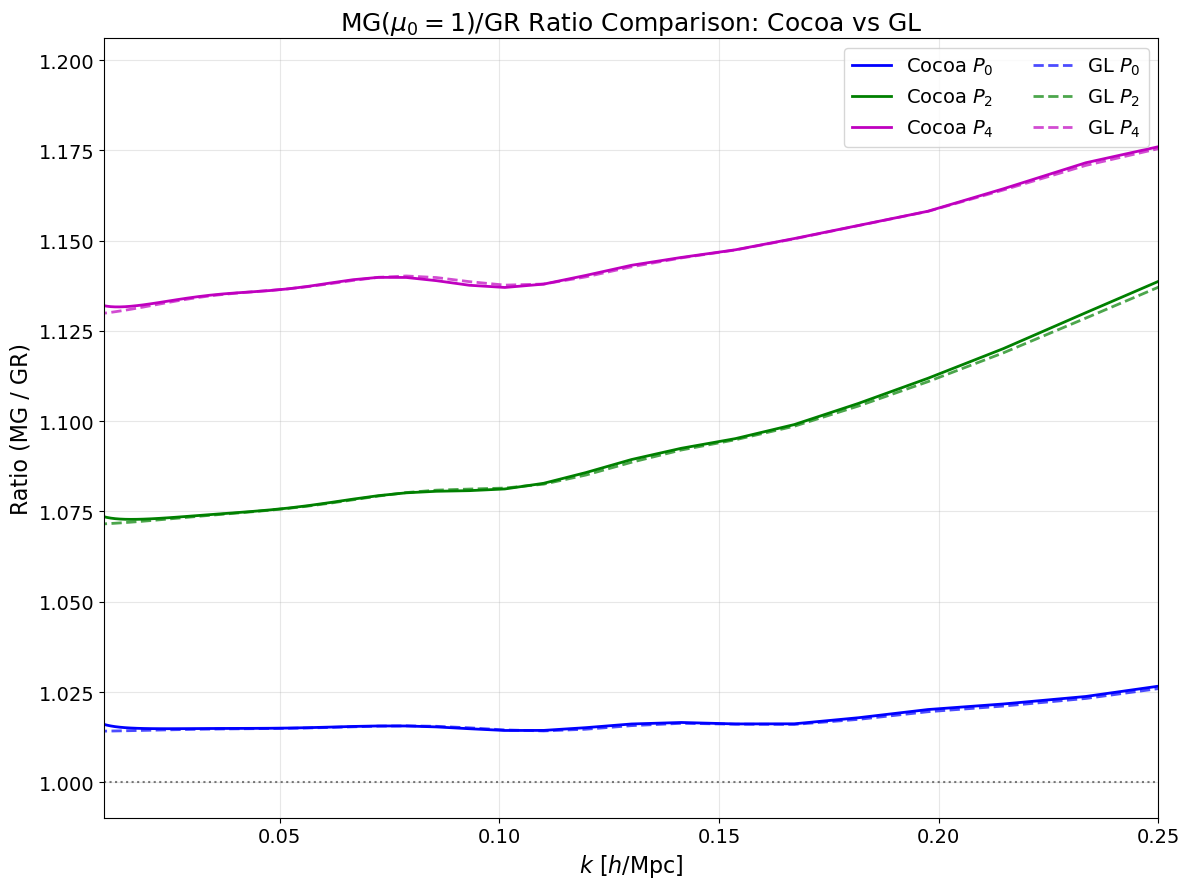

In [47]:
# --- MG / GR Ratio Comparison (Cocoa vs GL) ---


fig, ax = plt.subplots(1, 1, figsize=(12, 9))


# ---------------------------------------------------------

# 1. Cocoa (MGCAMB) の比率計算

# ---------------------------------------------------------

# GRのデータをMGのk軸に合わせて補間

p0_cc_gr_int = interp1d(kv_cc_gr, p0_cc_gr, bounds_error=False, fill_value="extrapolate")(kv_cc_mg)

p2_cc_gr_int = interp1d(kv_cc_gr, p2_cc_gr, bounds_error=False, fill_value="extrapolate")(kv_cc_mg)

p4_cc_gr_int = interp1d(kv_cc_gr, p4_cc_gr, bounds_error=False, fill_value="extrapolate")(kv_cc_mg)


ratio_cc_p0 = p0_cc_mg / p0_cc_gr_int

ratio_cc_p2 = p2_cc_mg / p2_cc_gr_int

ratio_cc_p4 = p4_cc_mg / p4_cc_gr_int


# ---------------------------------------------------------

# 2. GL (CosmoLike) の比率計算

# ---------------------------------------------------------

# GRのデータをMGのk軸に合わせて補間 (GLのデータ同士でも念のため)

p0_gl_gr_int = interp1d(kv_gl_gr, p0_gl_gr, bounds_error=False, fill_value="extrapolate")(kv_gl_mg)

p2_gl_gr_int = interp1d(kv_gl_gr, p2_gl_gr, bounds_error=False, fill_value="extrapolate")(kv_gl_mg)

p4_gl_gr_int = interp1d(kv_gl_gr, p4_gl_gr, bounds_error=False, fill_value="extrapolate")(kv_gl_mg)


ratio_gl_p0 = p0_gl_mg / p0_gl_gr_int

ratio_gl_p2 = p2_gl_mg / p2_gl_gr_int

ratio_gl_p4 = p4_gl_mg / p4_gl_gr_int


# ---------------------------------------------------------

# 3. プロット

# ---------------------------------------------------------


# --- Cocoa (Solid Lines) ---

ax.plot(kv_cc_mg, ratio_cc_p0, 'b-', label='Cocoa $P_0$', linewidth=2)

ax.plot(kv_cc_mg, ratio_cc_p2, 'g-', label='Cocoa $P_2$', linewidth=2)

ax.plot(kv_cc_mg, ratio_cc_p4, 'm-', label='Cocoa $P_4$', linewidth=2)


# --- GL (Dashed Lines) ---

ax.plot(kv_gl_mg, ratio_gl_p0, 'b--', label='GL $P_0$', linewidth=2, alpha=0.7)

ax.plot(kv_gl_mg, ratio_gl_p2, 'g--', label='GL $P_2$', linewidth=2, alpha=0.7)

ax.plot(kv_gl_mg, ratio_gl_p4, 'm--', label='GL $P_4$', linewidth=2, alpha=0.7)


# --- 装飾 ---

ax.axhline(1.0, color='k', linestyle=':', alpha=0.5)

ax.set_xlabel(r'$k \ [h/\mathrm{Mpc}]$', fontsize=16)

ax.set_ylabel(r'Ratio (MG / GR)', fontsize=16)

ax.set_title(r'MG($\mu_0=1$)/GR Ratio Comparison: Cocoa vs GL', fontsize=18)

ax.legend(fontsize=14, loc='best', ncol=2) # 2列にして見やすく

ax.grid(True, alpha=0.3)

ax.set_xlim(0.01, 0.25)

ax.tick_params(axis='both', labelsize=14)


plt.tight_layout()

plt.show()

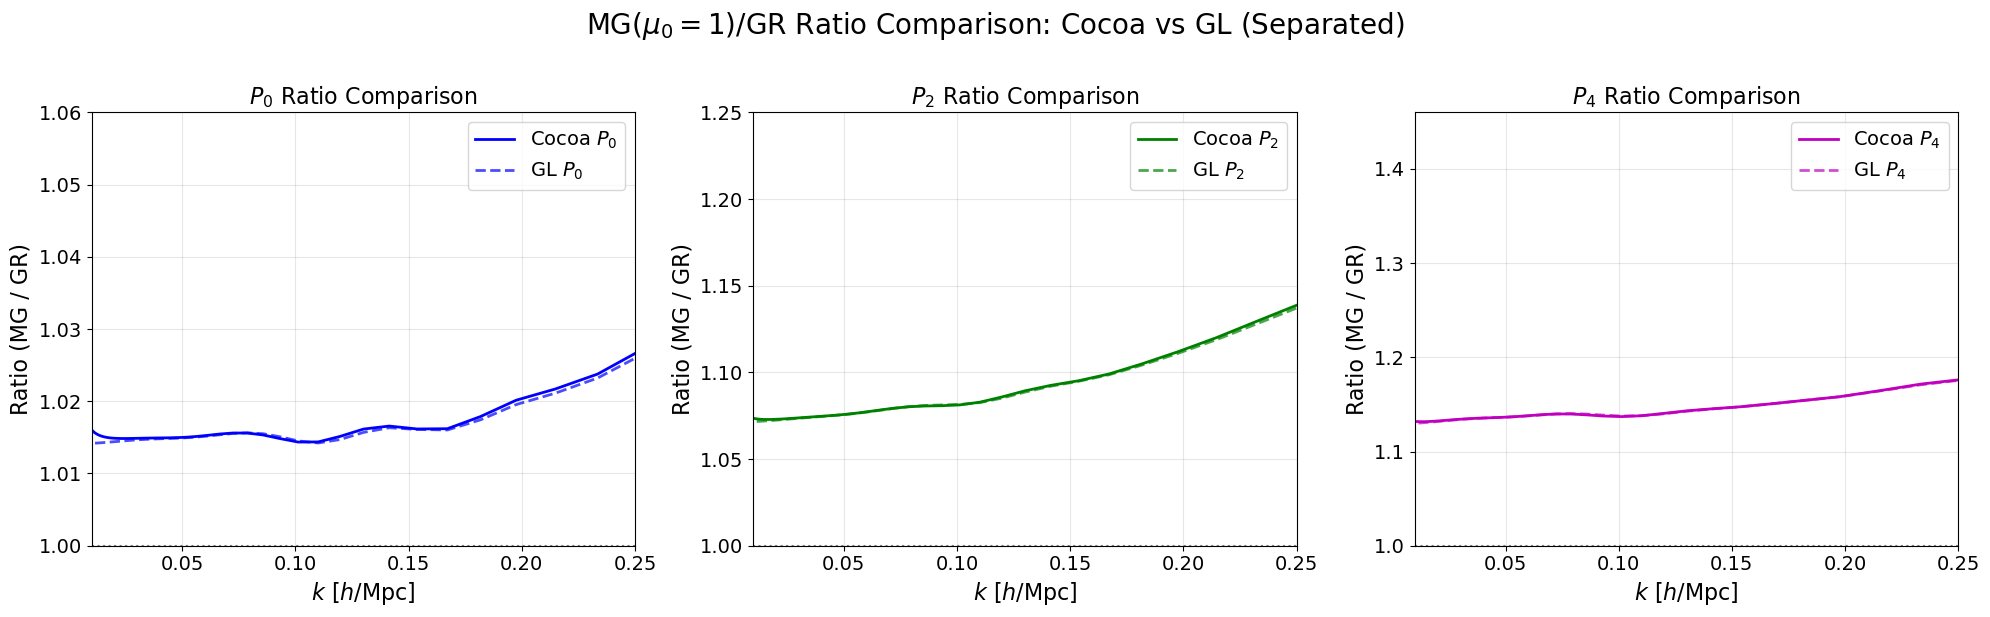

In [52]:
# ---------------------------------------------------------
# データ計算部分はそのまま維持 (省略せず記載します)
# ---------------------------------------------------------
# 1. Cocoa (MGCAMB) の比率計算
p0_cc_gr_int = interp1d(kv_cc_gr, p0_cc_gr, bounds_error=False, fill_value="extrapolate")(kv_cc_mg)
p2_cc_gr_int = interp1d(kv_cc_gr, p2_cc_gr, bounds_error=False, fill_value="extrapolate")(kv_cc_mg)
p4_cc_gr_int = interp1d(kv_cc_gr, p4_cc_gr, bounds_error=False, fill_value="extrapolate")(kv_cc_mg)

ratio_cc_p0 = p0_cc_mg / p0_cc_gr_int
ratio_cc_p2 = p2_cc_mg / p2_cc_gr_int
ratio_cc_p4 = p4_cc_mg / p4_cc_gr_int

# 2. GL (CosmoLike) の比率計算
p0_gl_gr_int = interp1d(kv_gl_gr, p0_gl_gr, bounds_error=False, fill_value="extrapolate")(kv_gl_mg)
p2_gl_gr_int = interp1d(kv_gl_gr, p2_gl_gr, bounds_error=False, fill_value="extrapolate")(kv_gl_mg)
p4_gl_gr_int = interp1d(kv_gl_gr, p4_gl_gr, bounds_error=False, fill_value="extrapolate")(kv_gl_mg)

ratio_gl_p0 = p0_gl_mg / p0_gl_gr_int
ratio_gl_p2 = p2_gl_mg / p2_gl_gr_int
ratio_gl_p4 = p4_gl_mg / p4_gl_gr_int

# ---------------------------------------------------------
# 3. プロット (3つのサブプロットに分割)
# ---------------------------------------------------------

# 1行3列のレイアウトを作成 (figsizeで横長に設定)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Plot 1: P0 ---
axes[0].plot(kv_cc_mg, ratio_cc_p0, 'b-', label='Cocoa $P_0$', linewidth=2)
axes[0].plot(kv_gl_mg, ratio_gl_p0, 'b--', label='GL $P_0$', linewidth=2, alpha=0.7)
axes[0].set_ylim(1.00, 1.06)
axes[0].set_title(r'$P_0$ Ratio Comparison', fontsize=16)

# --- Plot 2: P2 ---
axes[1].plot(kv_cc_mg, ratio_cc_p2, 'g-', label='Cocoa $P_2$', linewidth=2)
axes[1].plot(kv_gl_mg, ratio_gl_p2, 'g--', label='GL $P_2$', linewidth=2, alpha=0.7)
axes[1].set_ylim(1.00, 1.25)
axes[1].set_title(r'$P_2$ Ratio Comparison', fontsize=16)

# --- Plot 3: P4 ---
axes[2].plot(kv_cc_mg, ratio_cc_p4, 'm-', label='Cocoa $P_4$', linewidth=2)
axes[2].plot(kv_gl_mg, ratio_gl_p4, 'm--', label='GL $P_4$', linewidth=2, alpha=0.7)
axes[2].set_ylim(1.00, 1.46)
axes[2].set_title(r'$P_4$ Ratio Comparison', fontsize=16)

# --- 共通の装飾設定 ---
for ax in axes:
    ax.axhline(1.0, color='k', linestyle=':', alpha=0.5)
    ax.set_xlabel(r'$k \ [h/\mathrm{Mpc}]$', fontsize=16)
    ax.set_ylabel(r'Ratio (MG / GR)', fontsize=16)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0.01, 0.25)
    ax.tick_params(axis='both', labelsize=14)
    ax.legend(fontsize=14, loc='best')

# 全体のタイトル（必要であれば）
fig.suptitle(r'MG($\mu_0=1$)/GR Ratio Comparison: Cocoa vs GL (Separated)', fontsize=20, y=1.02)

plt.tight_layout()
plt.show()

## 260111 A_sを固定する場合での、GRとMGの比較。

Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)


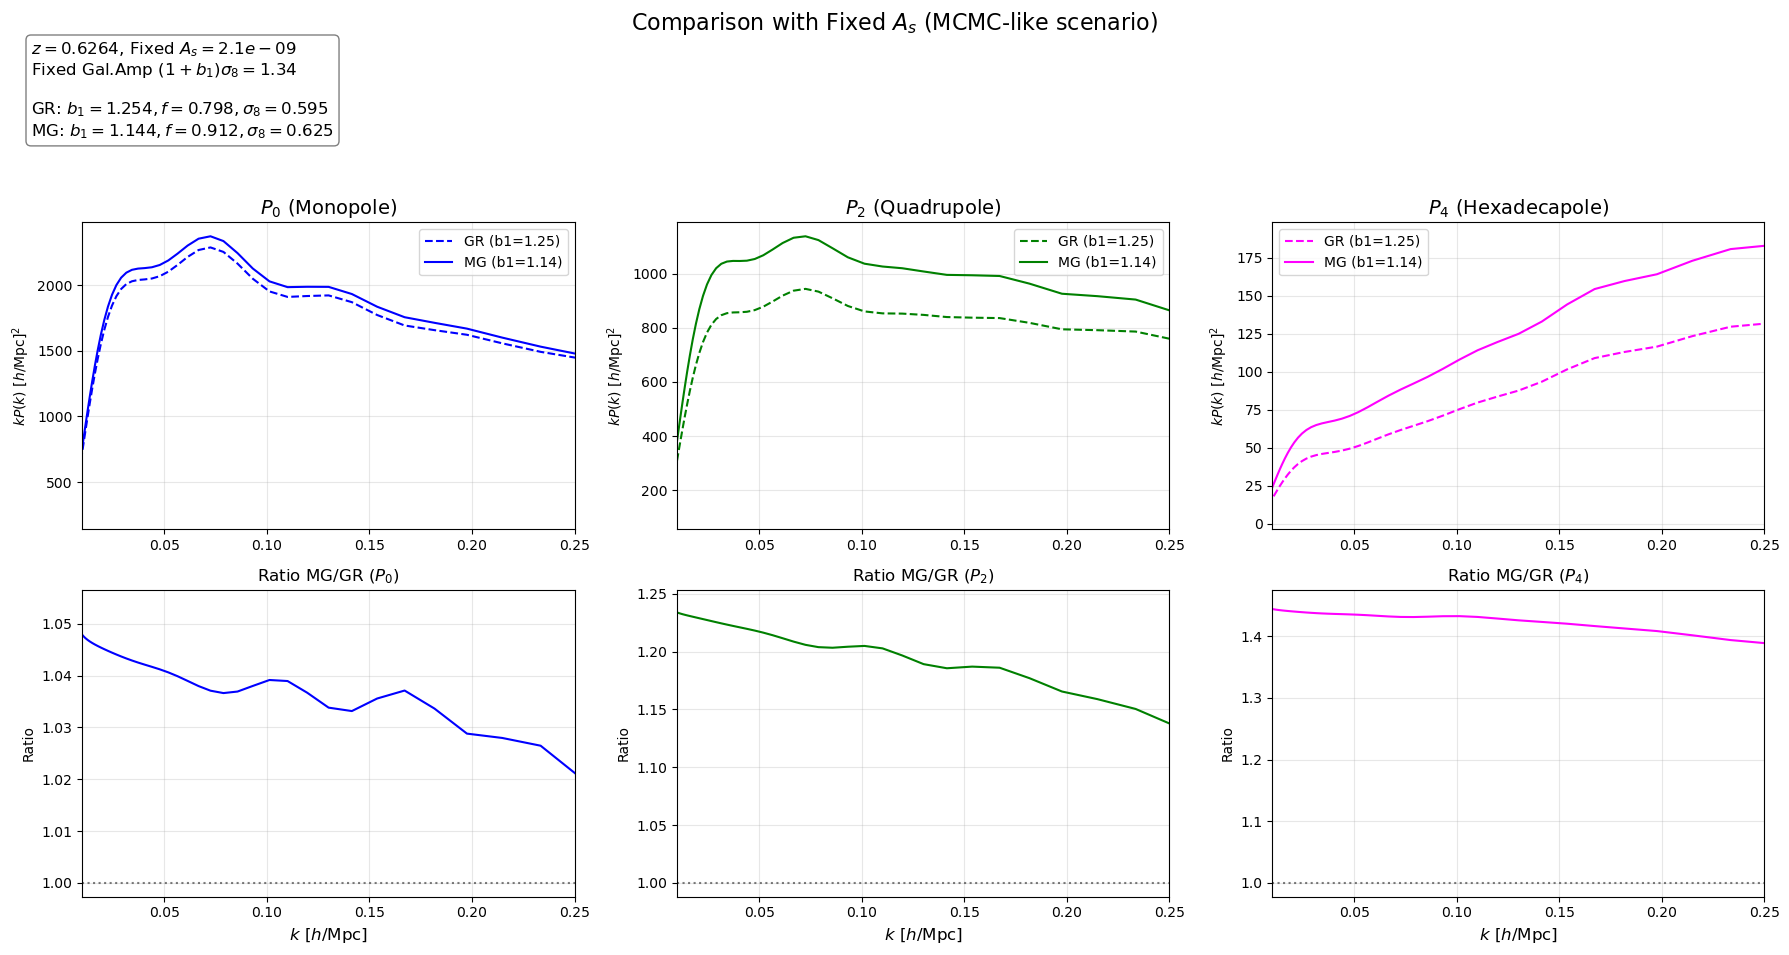

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from scipy.interpolate import interp1d
import camb
from velocileptors.LPT.moment_expansion_fftw import MomentExpansion

# --- 設定値 ---
z_eff = 0.6264
fixed_As = 2.1e-09  # GR/MGで共通の初期振幅
target_galaxy_amp = 1.34  # (1+b1)*sigma8 = constant (観測データ相当)

def get_mgcamb_data_fixed_As(mu0_val, As_val, z_target):
    """Asを固定して計算し、P(k), f, sigma8を返す"""
    h = 0.6732
    ob = 0.049389
    oc = 0.26503
    ns = 0.96605
    
    params = camb.CAMBparams()
    params.set_cosmology(H0=h*100, ombh2=ob*h**2, omch2=oc*h**2, mnu=0.0, omk=0, tau=0.0697186, nnu=3.046)
    
    params.MG_wrapped = True
    params.MG_flag = 1
    params.pure_MG_flag = 2
    params.muSigma_par = 1
    params.mu0 = mu0_val
    params.sigma0 = 0.0
    
    # Asを固定 (normalizeしない)
    params.InitPower.set_params(As=As_val, ns=ns)
    
    params.set_matter_power(redshifts=[0.0, z_target], kmax=20.0, nonlinear=False)
    results = camb.get_results(params)
    
    kh, z_out_pk, pk = results.get_matter_power_spectrum(minkh=1e-4, maxkh=20.0, npoints=2000)
    idx_pk = np.argmin(np.abs(np.array(z_out_pk) - z_target))
    pk_target = pk[idx_pk, :]
    
    z_out_trans = results.transfer_redshifts
    idx_trans = np.argmin(np.abs(np.array(z_out_trans) - z_target))
    s8_target = results.get_sigma8()[idx_trans]
    f_target = results.get_fsigma8()[idx_trans] / s8_target
    
    return kh, pk_target, f_target, s8_target

def compute_multipoles_with_fixed_amp(k, p_lin, f, s8, target_amp):
    """(1+b1)*sigma8 = target_amp となるようb1を逆算して多重極を計算"""
    b1 = (target_amp / s8) - 1.0
    mome = MomentExpansion(k, p_lin)
    pars = [b1, 0, 0, 0, 0, 0, 0, 0, 0]
    k_vec, p0, p2, p4 = mome.compute_redshift_space_power_multipoles(pars, f, reduced=True)
    return k_vec, p0, p2, p4, b1

# --- 計算実行 ---
# GR
k_gr, p_lin_gr, f_gr, s8_gr = get_mgcamb_data_fixed_As(0.0, fixed_As, z_eff)
kv_gr, p0_gr, p2_gr, p4_gr, b1_gr = compute_multipoles_with_fixed_amp(k_gr, p_lin_gr, f_gr, s8_gr, target_galaxy_amp)

# MG
k_mg, p_lin_mg, f_mg, s8_mg = get_mgcamb_data_fixed_As(1.0, fixed_As, z_eff)
kv_mg, p0_mg, p2_mg, p4_mg, b1_mg = compute_multipoles_with_fixed_amp(k_mg, p_lin_mg, f_mg, s8_mg, target_galaxy_amp)

# --- プロット ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# タイトルや情報を表示
info_text = (f"$z={z_eff}$, Fixed $A_s={fixed_As:.1e}$\n"
             f"Fixed Gal.Amp $(1+b_1)\sigma_8={target_galaxy_amp}$\n\n"
             f"GR: $b_1={b1_gr:.3f}, f={f_gr:.3f}, \sigma_8={s8_gr:.3f}$\n"
             f"MG: $b_1={b1_mg:.3f}, f={f_mg:.3f}, \sigma_8={s8_mg:.3f}$")
fig.suptitle("Comparison with Fixed $A_s$ (MCMC-like scenario)", fontsize=16)
fig.text(0.02, 0.95, info_text, fontsize=12, va='top', bbox=dict(boxstyle="round", facecolor="white", alpha=0.5))

# データリスト化してループ処理
data_list = [
    (p0_gr, p0_mg, '$P_0$ (Monopole)', 'blue'),
    (p2_gr, p2_mg, '$P_2$ (Quadrupole)', 'green'),
    (p4_gr, p4_mg, '$P_4$ (Hexadecapole)', 'magenta')
]

# Interpolation function for Ratio
def get_ratio(k_base, data_base, k_target, data_target):
    interp_func = interp1d(k_base, data_base, bounds_error=False, fill_value="extrapolate")
    return data_target / interp_func(k_target)

for i, (d_gr, d_mg, title, color) in enumerate(data_list):
    # --- 上段: 絶対値 (k * P(k)) ---
    ax_abs = axes[0, i]
    ax_abs.plot(kv_gr, kv_gr * d_gr, color=color, linestyle='--', label=f'GR (b1={b1_gr:.2f})')
    ax_abs.plot(kv_mg, kv_mg * d_mg, color=color, linestyle='-', label=f'MG (b1={b1_mg:.2f})')
    
    ax_abs.set_title(title, fontsize=14)
    ax_abs.set_ylabel(r'$k P(k) \ [h/\mathrm{Mpc}]^2$')
    ax_abs.legend()
    ax_abs.grid(True, alpha=0.3)
    ax_abs.set_xlim(0.01, 0.25)

    # --- 下段: Ratio (MG / GR) ---
    ax_rat = axes[1, i]
    ratio = get_ratio(kv_gr, d_gr, kv_mg, d_mg)
    ax_rat.plot(kv_mg, ratio, color=color, linestyle='-')
    
    ax_rat.axhline(1.0, color='k', linestyle=':', alpha=0.5)
    ax_rat.set_title(f'Ratio MG/GR ({title.split()[0]})', fontsize=12)
    ax_rat.set_xlabel(r'$k \ [h/\mathrm{Mpc}]$', fontsize=12)
    ax_rat.set_ylabel('Ratio')
    ax_rat.grid(True, alpha=0.3)
    ax_rat.set_xlim(0.01, 0.25)

plt.tight_layout(rect=[0, 0.03, 1, 0.85]) # タイトル分のスペース確保
plt.show()

## 260112 間違い
### 以下は、CAMBで"get_sigma8などのスカラー量は**z降順（過去→現在）で返ってきますが、get_matter_power_spectrumはコード内で反転処理されz昇順（現在→過去）で返ってきます。そのため、両者で配列の並び順が逆転しており、同じインデックスを使うと異なる時間を参照してしまう仕様になっています。"ことに気づかずに扱ったため、挙動が変になっております。

Note: redshifts have been re-sorted (earliest first)
mu0=0.0 | Initial s8_z0: 0.823335
mu0=0.0 | Normalized s8_z0: 0.812000
results.get_sigma8()[idx_zeff]: 0.8119999999999995
Note: redshifts have been re-sorted (earliest first)
mu0=1.0 | Initial s8_z0: 0.930571
mu0=1.0 | Normalized s8_z0: 0.812000
results.get_sigma8()[idx_zeff]: 0.8119999999999999


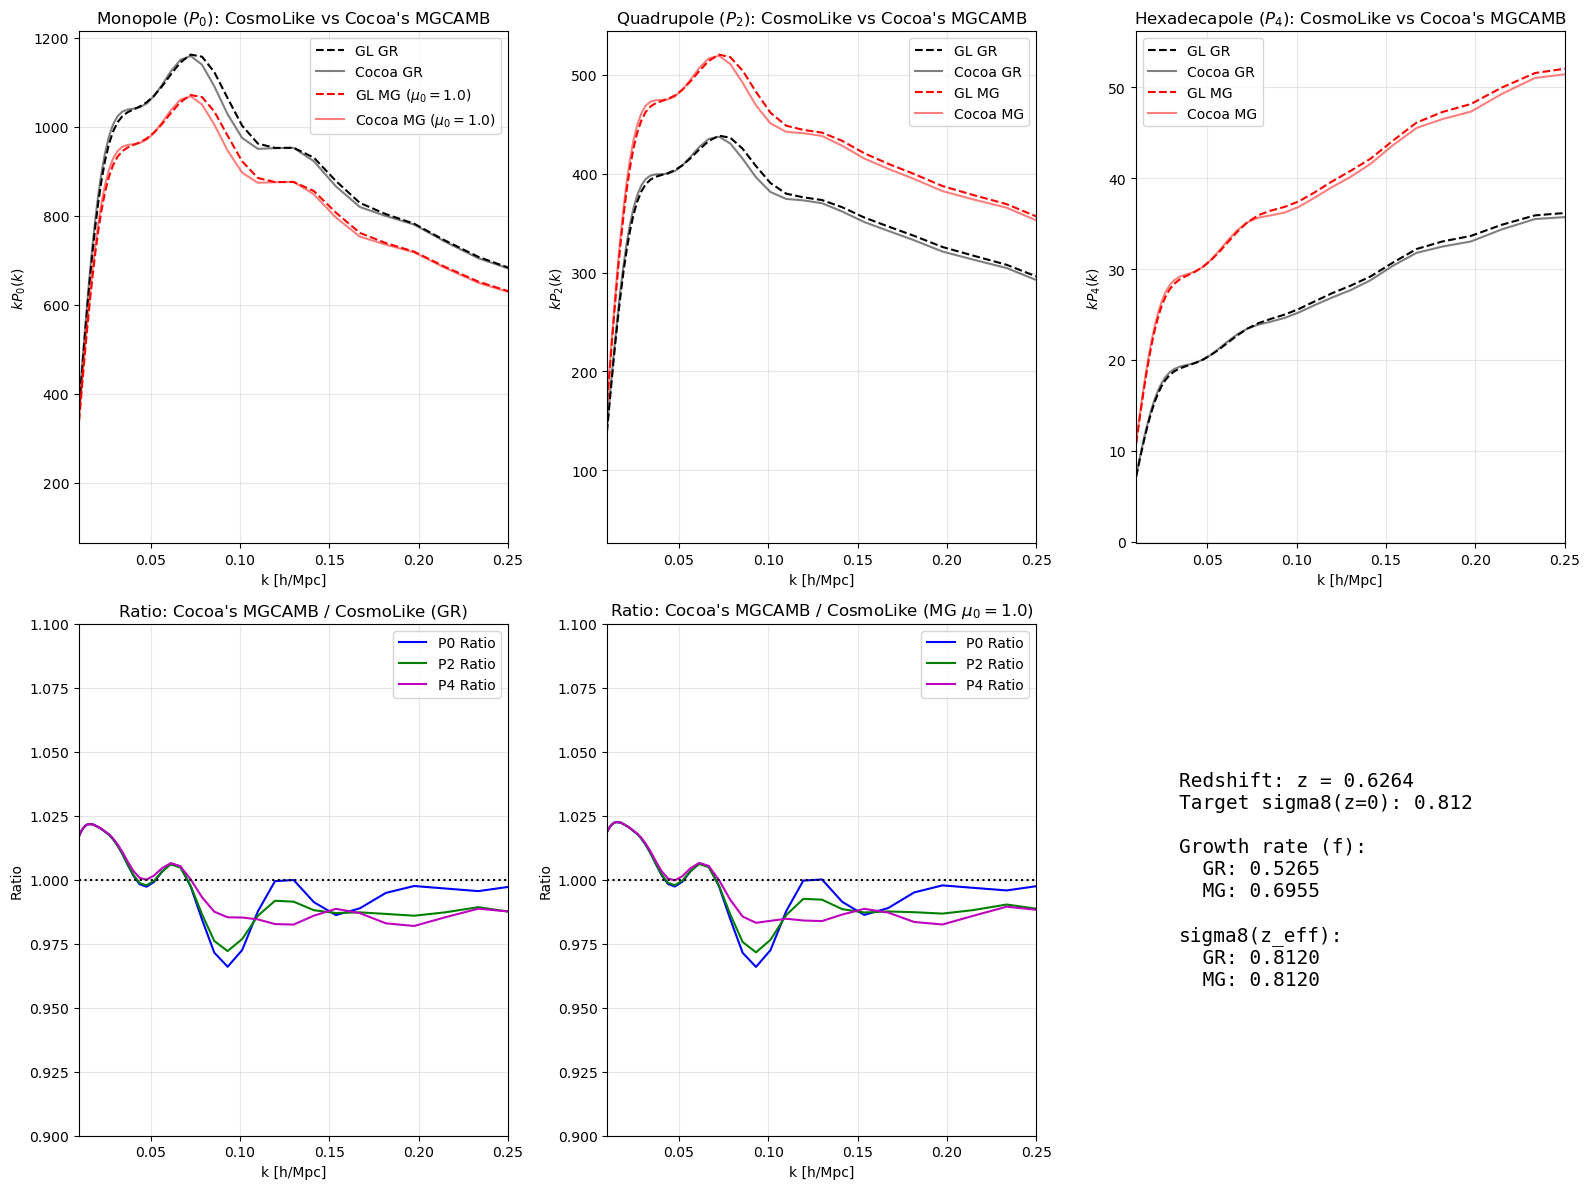

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from scipy.interpolate import interp1d

# --- パスの設定 ---
cocoa_root = "/home/tanida/cocoa_v41/cocoa/Cocoa"
mgcamb_path = os.path.join(cocoa_root, "external_modules/code/MGCAMB")
velocileptors_path = os.path.join(cocoa_root, "external_modules/code/velocileptors")

sys.path.insert(0, mgcamb_path)
sys.path.append(velocileptors_path)

import camb
from camb import model
from velocileptors.LPT.moment_expansion_fftw import MomentExpansion

def get_mgcamb_data(mu0_val, target_sigma8=0.8120, z_eff=0.6264):
    """
    MGCAMBを使用して、z_effでの線形パワースペクトル P(k) と成長率 f を取得する
    (z=0でのsigma8をtarget_sigma8に規格化)
    """
    # 以前の検証で特定した Planck パラメータ
    h = 0.6732
    ob = 0.049389
    oc = 0.26503
    ns = 0.96605
    
    params = camb.CAMBparams()
    params.set_cosmology(H0=h*100, ombh2=ob*h**2, omch2=oc*h**2, mnu=0.0, omk=0, tau=0.0697186, nnu=3.046)
    
    # MGCAMB設定 (mu-Sigmaモデル)
    params.MG_wrapped = True
    params.MG_flag = 1
    params.pure_MG_flag = 2
    # params.GRtrans = 0.2
    params.muSigma_par = 1
    params.mu0 = mu0_val
    params.sigma0 = 0.0
    params.InitPower.set_params(As=2.1e-09, ns=ns)

    # 1. z=0.0でのsigma8を確認してAsをスケール
    params.set_matter_power(redshifts=[0.0, z_eff], kmax=20.0, nonlinear=False)
    results = camb.get_results(params)
    s8_z0 = results.get_sigma8_0()
    print(f"mu0={mu0_val} | Initial s8_z0: {s8_z0:.6f}")
    
    new_As = 2.1e-09 * (target_sigma8 / s8_z0)**2
    params.InitPower.set_params(As=new_As, ns=ns)
    
    # 2. 本計算
    results = camb.get_results(params)
    kh, z_out, pk = results.get_matter_power_spectrum(minkh=1e-4, maxkh=20.0, npoints=2000)
    
    idx_zeff = np.argmin(np.abs(np.array(z_out) - z_eff))
    pk_zeff = pk[idx_zeff, :]
    
    # f = dlnD/dlna の取得
    fsigma8 = results.get_fsigma8()
    f_zeff = fsigma8[idx_zeff] / results.get_sigma8()[idx_zeff]

    print(f"mu0={mu0_val} | Normalized s8_z0: {results.get_sigma8_0():.6f}")
    print("results.get_sigma8()[idx_zeff]:", results.get_sigma8()[idx_zeff] )
    
    return kh, pk_zeff, f_zeff, results.get_sigma8()[idx_zeff]

def compute_pt_multipoles(k_lin, p_lin, f_z, sigma8_z):
    """
    velocileptors (LPT Moment Expansion) を使用して多重極を計算
    """
    mome = MomentExpansion(k_lin, p_lin)
    
    # バイアスパラメータの設定
    # (1 + b1) * sigma8(z) = 1.34 と仮定
    b1 = (1.34 / sigma8_z) - 1.0
    
    # その他の高次パラメータは0（線形比較のため）
    pars = [b1, 0, 0, 0, 0, 0, 0, 0, 0] # [b1, b2, bs, b3, alpha0, alpha2, alpha4, SN0, SN2]
    
    k_vec, p0, p2, p4 = mome.compute_redshift_space_power_multipoles(pars, f_z, reduced=True)
    return k_vec, p0, p2, p4

# --- メイン処理 ---
z_eff = 0.6264
target_sigma8 = 0.8120
gl_path = "/home/tanida/GL/valid_test/power/"

# 1. GLデータの読み込み
k_gl_gr, p_gl_gr = np.loadtxt(os.path.join(gl_path, "CMASS2_0000.dat"), unpack=True)
k_gl_mg, p_gl_mg = np.loadtxt(os.path.join(gl_path, "CMASS2_1000.dat"), unpack=True)

# 2. Cocoa (MGCAMB) データの生成
kh_cc_gr, p_cc_gr, f_gr, s8_gr = get_mgcamb_data(0.0, target_sigma8, z_eff)
kh_cc_mg, p_cc_mg, f_mg, s8_mg = get_mgcamb_data(1.0, target_sigma8, z_eff)

# 3. Velocileptors による PT 多重極の計算
# GLベース
kv_gl_gr, p0_gl_gr, p2_gl_gr, p4_gl_gr = compute_pt_multipoles(k_gl_gr, p_gl_gr, f_gr, s8_gr)
kv_gl_mg, p0_gl_mg, p2_gl_mg, p4_gl_mg = compute_pt_multipoles(k_gl_mg, p_gl_mg, f_mg, s8_mg)

# Cocoaベース
kv_cc_gr, p0_cc_gr, p2_cc_gr, p4_cc_gr = compute_pt_multipoles(kh_cc_gr, p_cc_gr, f_gr, s8_gr)
kv_cc_mg, p0_cc_mg, p2_cc_mg, p4_cc_mg = compute_pt_multipoles(kh_cc_mg, p_cc_mg, f_mg, s8_mg)

# --- プロット ---
fig, axes = plt.subplots(2, 3, figsize=(16, 12))

# Monopole (P0)
ax = axes[0, 0]
ax.plot(kv_gl_gr, kv_gl_gr * p0_gl_gr, 'k--', label='GL GR')
ax.plot(kv_cc_gr, kv_cc_gr * p0_cc_gr, 'k-', alpha=0.5, label='Cocoa GR')
ax.plot(kv_gl_mg, kv_gl_mg * p0_gl_mg, 'r--', label='GL MG ($\mu_0=1.0$)')
ax.plot(kv_cc_mg, kv_cc_mg * p0_cc_mg, 'r-', alpha=0.5, label='Cocoa MG ($\mu_0=1.0$)')
ax.set_title("Monopole ($P_0$): CosmoLike vs Cocoa's MGCAMB")
ax.set_ylabel('$k P_0(k)$')
ax.legend()

# Quadrupole (P2)
ax = axes[0, 1]
ax.plot(kv_gl_gr, kv_gl_gr * p2_gl_gr, 'k--', label='GL GR')
ax.plot(kv_cc_gr, kv_cc_gr * p2_cc_gr, 'k-', alpha=0.5, label='Cocoa GR')
ax.plot(kv_gl_mg, kv_gl_mg * p2_gl_mg, 'r--', label='GL MG')
ax.plot(kv_cc_mg, kv_cc_mg * p2_cc_mg, 'r-', alpha=0.5, label='Cocoa MG')
ax.set_title("Quadrupole ($P_2$): CosmoLike vs Cocoa's MGCAMB")
ax.set_ylabel('$k P_2(k)$')
ax.legend()

# Hexadecapole (P4)
ax = axes[0, 2]
ax.plot(kv_gl_gr, kv_gl_gr * p4_gl_gr, 'k--', label='GL GR')
ax.plot(kv_cc_gr, kv_cc_gr * p4_cc_gr, 'k-', alpha=0.5, label='Cocoa GR')
ax.plot(kv_gl_mg, kv_gl_mg * p4_gl_mg, 'r--', label='GL MG')
ax.plot(kv_cc_mg, kv_cc_mg * p4_cc_mg, 'r-', alpha=0.5, label='Cocoa MG')
ax.set_title("Hexadecapole ($P_4$): CosmoLike vs Cocoa's MGCAMB")
ax.set_ylabel('$k P_4(k)$')
ax.legend()

# Ratio Cocoa/GL (GR)
ax = axes[1, 0]
p0_ratio_gr = p0_cc_gr / interp1d(kv_gl_gr, p0_gl_gr, bounds_error=False)(kv_cc_gr)
p2_ratio_gr = p2_cc_gr / interp1d(kv_gl_gr, p2_gl_gr, bounds_error=False)(kv_cc_gr)
p4_ratio_gr = p4_cc_gr / interp1d(kv_gl_gr, p4_gl_gr, bounds_error=False)(kv_cc_gr)
ax.plot(kv_cc_gr, p0_ratio_gr, 'b-', label='P0 Ratio')
ax.plot(kv_cc_gr, p2_ratio_gr, 'g-', label='P2 Ratio')
ax.plot(kv_cc_gr, p4_ratio_gr, 'm-', label='P4 Ratio')
ax.axhline(1.0, color='k', linestyle=':')
ax.set_title("Ratio: Cocoa's MGCAMB / CosmoLike (GR)")
ax.set_ylabel("Ratio")
ax.set_ylim(0.90, 1.10)
ax.legend()

# Ratio Cocoa/GL (MG)
ax = axes[1, 1]
p0_ratio_mg = p0_cc_mg / interp1d(kv_gl_mg, p0_gl_mg, bounds_error=False)(kv_cc_mg)
p2_ratio_mg = p2_cc_mg / interp1d(kv_gl_mg, p2_gl_mg, bounds_error=False)(kv_cc_mg)
p4_ratio_mg = p4_cc_mg / interp1d(kv_gl_mg, p4_gl_mg, bounds_error=False)(kv_cc_mg)
ax.plot(kv_cc_mg, p0_ratio_mg, 'b-', label='P0 Ratio')
ax.plot(kv_cc_mg, p2_ratio_mg, 'g-', label='P2 Ratio')
ax.plot(kv_cc_mg, p4_ratio_mg, 'm-', label='P4 Ratio')
ax.axhline(1.0, color='k', linestyle=':')
ax.set_title("Ratio: Cocoa's MGCAMB / CosmoLike (MG $\mu_0=1.0$)")
ax.set_ylabel("Ratio")
ax.set_ylim(0.90, 1.10)
ax.legend()

# Slot axes[1, 2] に成長率の情報を表示
ax = axes[1, 2]
ax.axis('off')
text_info = f"Redshift: z = {z_eff}\n" \
            f"Target sigma8(z=0): {target_sigma8}\n\n" \
            f"Growth rate (f):\n" \
            f"  GR: {f_gr:.4f}\n" \
            f"  MG: {f_mg:.4f}\n\n" \
            f"sigma8(z_eff):\n" \
            f"  GR: {s8_gr:.4f}\n" \
            f"  MG: {s8_mg:.4f}"
ax.text(0.1, 0.5, text_info, fontsize=14, family='monospace', verticalalignment='center')

for ax in axes.flatten():
    if ax.axison:
        ax.set_xlabel('k [h/Mpc]')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0.01, 0.25)

plt.tight_layout()
plt.show()